# 20260712_EDA_2024_서울_시도분리정제

- 작성자: 이정연
- #3 이슈 참고 
- 공통 함수는 일단 따로 안만들고, 이 노트북에서 진행해보고 결정해서 유틸로 분리하는 방식으로 진행

In [1]:
# 라이브러리 임포트 
import re
from pathlib import Path

import pandas as pd
import numpy as np
import openpyxl

# 경로 설정
DATA_DIR = Path('../data/raw')
INTERIM_DIR = Path('../data/interim')
REPORTS_DIR = Path("../reports")

# 출력 설정
pd.set_option("display.max_rows", None) # 행 생략 없이 전부 표시 
pd.set_option("display.max_columns", None) # 열 생략 없이 전부 표시 
pd.set_option("display.max_colwidth", None) # 셀 안 텍스트 길이 안 자르고 전부 표시 

## 기본 검사 

In [2]:
# 데이터 불러오기 
file_2024 = Path(DATA_DIR)/"세부사업표추출_2024년도 지방자치단체 저출산고령사회 시행계획 (제4차 기본계획).xlsx"
df_raw = pd.read_excel(file_2024, sheet_name="Table 1", header=None)

print(df_raw.shape)
df_raw.head(10)

(8234, 15)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,붙임 (서울특별시 서울특별시교육청),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,세부사업명,NaN,공통/ 자체,NaN,2024년 예산,NaN,NaN,2023년예산 (최종예산),NaN,증감내역,NaN,NaN,NaN,NaN,주요내용
3,NaN,NaN,NaN,NaN,총예산(a),NaN,NaN,총예산(b),NaN,증감액(a-b),NaN,증감율,NaN,NaN,NaN
4,Ⅰ. 공통사업,NaN,NaN,NaN,3906937,NaN,NaN,3952421.7,NaN,45485,NaN,1,NaN,NaN,NaN
5,1. 함께 일하고 함께 돌보는 사회(공통),NaN,공통,NaN,3260099,NaN,NaN,3058321,NaN,201778,NaN,7,NaN,NaN,NaN
6,저출생 극복 지역네트워크 구축사업 지원,NaN,공통,NaN,54,NaN,NaN,108,NaN,-54,NaN,-50,NaN,NaN,지원대상 : 서울시민(3~7세 자녀가 있는 가정)\n지원내용:서울100인의아빠단
7,입양아동 가족지원,NaN,공통,NaN,4002,NaN,NaN,4345,NaN,-343,NaN,-8,NaN,NaN,"지원대상 : 입양특례법에 의한 18세미만 입양 아동 및 그 가정 지원내용:입양아동양육보조금,양육수당,입양비용등"
8,국공립어린이집 등 보육서비스\n수준제고,NaN,공통,NaN,459506,NaN,NaN,450562,NaN,8944,NaN,2,NaN,NaN,지원대상 : 국공립 어린이집 등 지원내용:보육교직원인건비지원
9,어린이집 이용 영유아 무상보육 확대,NaN,공통,NaN,554805,NaN,NaN,654969,NaN,-100164,NaN,-15,NaN,NaN,지원대상 : 만0~2세 영아 지원내용:어린이집이용영아대상바우처지원


In [3]:
# 붙임 (00시 00교육청) 타이틀 행에서 시도명 추출
# 원본 Pdf to excel 변환 과정에서 글자 사이에 공백이 들어가는 경우가 있어 공백 제거 후 매칭

# 정규식 패턴 
sido_title_pattern = re.compile(r"붙\s*임\s*\(([^)]+)\)")

def find_sido_boundaries(df: pd.DataFrame) -> pd.DataFrame:
  """시트 전체에서 시도 경계 타이틀 행을 찾아 (행번호, 원문, 시도명) 변환"""
  boundaries = []
  for row_idx, row in df.iterrows():
    for value in row: # 행의 모든 열 검사 
      if not isinstance(value, str): 
        continue # 문자열 아니면 건너뜀 
      match = sido_title_pattern.search(value)
      if match: 
        boundaries.append(
          {'row': row_idx, "raw_text": value.strip(), "sido_row": match.group(1).strip()}
        )
        break
  return pd.DataFrame(boundaries)

In [4]:
boundaries_df = find_sido_boundaries(df_raw)
boundaries_df

,row,raw_text,sido_row
0,0,붙임 (서울특별시 서울특별시교육청),서울특별시 서울특별시교육청
1,285,붙임 (부산광역시 부산광역시교육청),부산광역시 부산광역시교육청
2,1056,붙임 (대구광역시 대구광역시교육청),대구광역시 대구광역시교육청
3,1359,붙임 (인천광역시 인천광역시교육청),인천광역시 인천광역시교육청
4,1743,붙임 (광주광역시 광주광역시교육청),광주광역시 광주광역시교육청
5,1979,붙임 (대전광역시 대전광역시교육청),대전광역시 대전광역시교육청
6,2173,붙임 (울산광역시 울산광역시교육청),울산광역시 울산광역시교육청
7,2523,붙임 (세종특별자치시 세종특별자치시교육청),세종특별자치시 세종특별자치시교육청
8,2669,붙임 (경기도 경기도교육청),경기도 경기도교육청
9,4150,붙임 (강원도 강원도교육청),강원도 강원도교육청


In [5]:
# 소관기관 파싱 -> (시도, 소관기관) 분리
def split_sido_agency(sido_raw: str) -> tuple[str, str | None]:
  parts = sido_raw.split()
  if len(parts) == 2:
    return parts[0], parts[1]
  return sido_raw, None # 소관기관 없는 케이스 

boundaries_df[["시도", "소관기관"]] = boundaries_df["sido_row"].apply(
  lambda x: pd.Series(split_sido_agency(x))
)

boundaries_df

,row,raw_text,sido_row,시도,소관기관
0,0,붙임 (서울특별시 서울특별시교육청),서울특별시 서울특별시교육청,서울특별시,서울특별시교육청
1,285,붙임 (부산광역시 부산광역시교육청),부산광역시 부산광역시교육청,부산광역시,부산광역시교육청
2,1056,붙임 (대구광역시 대구광역시교육청),대구광역시 대구광역시교육청,대구광역시,대구광역시교육청
3,1359,붙임 (인천광역시 인천광역시교육청),인천광역시 인천광역시교육청,인천광역시,인천광역시교육청
4,1743,붙임 (광주광역시 광주광역시교육청),광주광역시 광주광역시교육청,광주광역시,광주광역시교육청
5,1979,붙임 (대전광역시 대전광역시교육청),대전광역시 대전광역시교육청,대전광역시,대전광역시교육청
6,2173,붙임 (울산광역시 울산광역시교육청),울산광역시 울산광역시교육청,울산광역시,울산광역시교육청
7,2523,붙임 (세종특별자치시 세종특별자치시교육청),세종특별자치시 세종특별자치시교육청,세종특별자치시,세종특별자치시교육청
8,2669,붙임 (경기도 경기도교육청),경기도 경기도교육청,경기도,경기도교육청
9,4150,붙임 (강원도 강원도교육청),강원도 강원도교육청,강원도,강원도교육청


In [6]:
# 시도 각각의 구간(범위) 구하기 
boundaries_df["end"] = boundaries_df['row'].shift(-1) # 컬럼 값을 한 칸씩 위로 땡기기
boundaries_df.loc[boundaries_df.index[-1], "end"] = len(df_raw) # 제주도의 경우에는 end = NaN 니까 끝지점으로 채워줌
boundaries_df["end"] = boundaries_df["end"].astype(int) # 슬라이싱을 위해 int 타입으로 변환

boundaries_df[["시도", "소관기관", 'row', "end"]]

,시도,소관기관,row,end
0,서울특별시,서울특별시교육청,0,285
1,부산광역시,부산광역시교육청,285,1056
2,대구광역시,대구광역시교육청,1056,1359
3,인천광역시,인천광역시교육청,1359,1743
4,광주광역시,광주광역시교육청,1743,1979
5,대전광역시,대전광역시교육청,1979,2173
6,울산광역시,울산광역시교육청,2173,2523
7,세종특별자치시,세종특별자치시교육청,2523,2669
8,경기도,경기도교육청,2669,4150
9,강원도,강원도교육청,4150,4716


In [7]:
# 서울 구간 슬라이싱
def slice_sido(df_raw: pd.DataFrame, boundaries_df: pd.DataFrame, sido: str) -> pd.DataFrame:
  "boundaries_df 에서 시도명으로 구간을 찾아 df_raw를 잘라서 변환"
  row_info = boundaries_df.loc[boundaries_df["시도"] == sido].iloc[0]
  return df_raw[row_info["row"]: row_info["end"]].reset_index(drop=True)

df_seoul_raw = slice_sido(df_raw, boundaries_df, "서울특별시")
print(df_seoul_raw.shape)
df_seoul_raw.head(5)

(285, 15)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,붙임 (서울특별시 서울특별시교육청),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,세부사업명,NaN,공통/ 자체,NaN,2024년 예산,NaN,NaN,2023년예산 (최종예산),NaN,증감내역,NaN,NaN,NaN,NaN,주요내용
3,NaN,NaN,NaN,NaN,총예산(a),NaN,NaN,총예산(b),NaN,증감액(a-b),NaN,증감율,NaN,NaN,NaN
4,Ⅰ. 공통사업,NaN,NaN,NaN,3906937,NaN,NaN,3952421.7,NaN,45485,NaN,1,NaN,NaN,NaN


- 0행 = 붙임 타이틀
- 1행 = 빈행
- 2행 = 상단 헤더 
- 3행 = 하단 헤더 

-> 기본값 (2,3)으로 설정

In [8]:
# 병합 헤더 평탄화 
def flatten_header(df_sido_raw: pd.DataFrame, header_rows: tuple[int, int] = (2, 3)) -> tuple[list[str], int]:
  """구간 raw_df 안의 2단 병합 헤더를 단일 컬럼명으로 평탄화
  header_rows: (상단 헤더 행, 하단 헤더 행) - 시도 구간 내부 기준 상대 인덱스
  반환: (평탄화된 컬럼명 리스트, 실제 데이터가 시작하는 행 인덱스)
  """

  # 헤더 두 줄 꺼내기 
  top = df_sido_raw.iloc[header_rows[0]].ffill() # 병합셀은 왼쪽 값만 있고, 나머지 NaN이라 ffill로 채움 
  sub = df_sido_raw.iloc[header_rows[1]]

  # 두 헤더 하나로 합치기 
  flat_names = []
  seen = {}
  for t, s in zip(top, sub):
    t, s = str(t).strip(), str(s).strip()
    if s in ("nan", "") or s == t:
      name = t
    else:
      name = f"{t}_{s}"

    # 병합으로 생긴 빈 열이 dropna로 다 제거된다는 보장이 없어서(다른 시도/연도에서
    # 빈 열에 값이 하나라도 남아있으면 중복 컬럼명이 생김), 여기서 미리 접미사로 구분
    if name in seen:
      seen[name] += 1
      name = f"{name}_{seen[name]}"
    else:
      seen[name] = 0

    flat_names.append(name)
  
  # 데이터가 시작하는 행 번호 계산 
  data_start = header_rows[1] + 1
  return flat_names, data_start

columns, data_start = flatten_header(df_seoul_raw)
print(columns)

df_seoul = df_seoul_raw.iloc[data_start:].copy()
df_seoul.columns = columns
df_seoul = df_seoul.reset_index(drop=True)
df_seoul.head(10)
    

['세부사업명', '세부사업명_1', '공통/ 자체', '공통/ 자체_1', '2024년 예산_총예산(a)', '2024년 예산', '2024년 예산_1', '2023년예산 (최종예산)_총예산(b)', '2023년예산 (최종예산)', '증감내역_증감액(a-b)', '증감내역', '증감내역_증감율', '증감내역_1', '증감내역_2', '주요내용']


,세부사업명,세부사업명_1,공통/ 자체,공통/ 자체_1,2024년 예산_총예산(a),2024년 예산,2024년 예산_1,2023년예산 (최종예산)_총예산(b),2023년예산 (최종예산),증감내역_증감액(a-b),증감내역,증감내역_증감율,증감내역_1,증감내역_2,주요내용
0,Ⅰ. 공통사업,NaN,NaN,NaN,3906937,NaN,NaN,3952421.7,NaN,45485,NaN,1,NaN,NaN,NaN
1,1. 함께 일하고 함께 돌보는 사회(공통),NaN,공통,NaN,3260099,NaN,NaN,3058321,NaN,201778,NaN,7,NaN,NaN,NaN
2,저출생 극복 지역네트워크 구축사업 지원,NaN,공통,NaN,54,NaN,NaN,108,NaN,-54,NaN,-50,NaN,NaN,지원대상 : 서울시민(3~7세 자녀가 있는 가정)\n지원내용:서울100인의아빠단
3,입양아동 가족지원,NaN,공통,NaN,4002,NaN,NaN,4345,NaN,-343,NaN,-8,NaN,NaN,"지원대상 : 입양특례법에 의한 18세미만 입양 아동 및 그 가정 지원내용:입양아동양육보조금,양육수당,입양비용등"
4,국공립어린이집 등 보육서비스\n수준제고,NaN,공통,NaN,459506,NaN,NaN,450562,NaN,8944,NaN,2,NaN,NaN,지원대상 : 국공립 어린이집 등 지원내용:보육교직원인건비지원
5,어린이집 이용 영유아 무상보육 확대,NaN,공통,NaN,554805,NaN,NaN,654969,NaN,-100164,NaN,-15,NaN,NaN,지원대상 : 만0~2세 영아 지원내용:어린이집이용영아대상바우처지원
6,초등돌봄 공적\n인프라 확충,NaN,공통,NaN,1141,NaN,NaN,5087,NaN,-3946,NaN,-78,NaN,NaN,지원대상 : 6~12세 아동\n지원내용:돌봄서비스제공
7,육아종합지원센터 운영,NaN,공통,NaN,2244,NaN,NaN,2476,NaN,-232,NaN,-9,NaN,NaN,"지원대상 : 어린이집 및 영유아 양육 가정 지원내용\n어린이집 지원사업 : 어린이집 맞춤 컨설팅, 장애아지원 교육 보육교직원 교육 및 상담, 서울형 모아어린이집 운영지원 등\n가정양육 지원사업 : 장난감도서관 운영, 시\n간제보육 관리등"
8,가정양육수당 지원,NaN,공통,NaN,44151,NaN,NaN,55556,NaN,-11405,NaN,-21,NaN,NaN,지원대상 : 시설 미이용 24개월~86개월 미만 아동 지원내용:월10만원(장애아동35개월미만20만원) 지원
9,부모급여,NaN,공통,NaN,688871,NaN,NaN,388889,NaN,299982,NaN,77,NaN,NaN,"지원대상 : 0~1세 아동\n지원내용:0세100만원(월),1세50만원(월)지원"


In [9]:
# 전부 NaN인 빈 컬럼 걸러내기
df_seoul = df_seoul_raw.iloc[data_start: ].copy()
df_seoul.columns = columns
df_seoul = df_seoul.dropna(axis=1, how='all') # 병합으로 생긴 빈 열 제거 
df_seoul = df_seoul.reset_index(drop=True)
df_seoul.head(10)

,세부사업명,공통/ 자체,2024년 예산_총예산(a),2023년예산 (최종예산)_총예산(b),증감내역_증감액(a-b),증감내역_증감율,주요내용
0,Ⅰ. 공통사업,NaN,3906937,3952421.7,45485,1,NaN
1,1. 함께 일하고 함께 돌보는 사회(공통),공통,3260099,3058321,201778,7,NaN
2,저출생 극복 지역네트워크 구축사업 지원,공통,54,108,-54,-50,지원대상 : 서울시민(3~7세 자녀가 있는 가정)\n지원내용:서울100인의아빠단
3,입양아동 가족지원,공통,4002,4345,-343,-8,"지원대상 : 입양특례법에 의한 18세미만 입양 아동 및 그 가정 지원내용:입양아동양육보조금,양육수당,입양비용등"
4,국공립어린이집 등 보육서비스\n수준제고,공통,459506,450562,8944,2,지원대상 : 국공립 어린이집 등 지원내용:보육교직원인건비지원
5,어린이집 이용 영유아 무상보육 확대,공통,554805,654969,-100164,-15,지원대상 : 만0~2세 영아 지원내용:어린이집이용영아대상바우처지원
6,초등돌봄 공적\n인프라 확충,공통,1141,5087,-3946,-78,지원대상 : 6~12세 아동\n지원내용:돌봄서비스제공
7,육아종합지원센터 운영,공통,2244,2476,-232,-9,"지원대상 : 어린이집 및 영유아 양육 가정 지원내용\n어린이집 지원사업 : 어린이집 맞춤 컨설팅, 장애아지원 교육 보육교직원 교육 및 상담, 서울형 모아어린이집 운영지원 등\n가정양육 지원사업 : 장난감도서관 운영, 시\n간제보육 관리등"
8,가정양육수당 지원,공통,44151,55556,-11405,-21,지원대상 : 시설 미이용 24개월~86개월 미만 아동 지원내용:월10만원(장애아동35개월미만20만원) 지원
9,부모급여,공통,688871,388889,299982,77,"지원대상 : 0~1세 아동\n지원내용:0세100만원(월),1세50만원(월)지원"


In [10]:
# 컬럼명 정제 
df_seoul.columns = [re.sub(r"\s+", "", c) if isinstance(c, str) else c for c in df_seoul.columns]

# 텍스트 값 정제 
text_cols = ["세부사업명", "공통/자체", "주요내용"]

for col in text_cols:
  if col in df_seoul.columns:
    df_seoul[col] = df_seoul[col].apply(
      lambda x: re.sub(r"\s+", " ", str(x)).strip() if pd.notna(x) else x
    )

In [ ]:
# 대분류 값을 세부사업 행들에 컬럼으로 붙이기 
# classify_row 수정 
def classify_row(세부사업명: str) -> str: 
  """대분류_소계 / 중분류_소계 / 헤더반복 / 세부사업 행 판별"""
  if pd.isna(세부사업명) or str(세부사업명).strip() == "":
    return "헤더반복"

  name = str(세부사업명).strip()

  # 셀 48-51에서 확인한 페이지마다 반복된 헤더 줄 예외 추가
  if name == "세부사업명":
    return "헤더반복"
  if re.match(r"^[Ⅰ-Ⅿ]", name):  # 유니코드 로마숫자 대문자 전체 블록(Ⅰ~ⅬⅭⅮⅯ) - 대분류 10개(Ⅹ) 초과 대비
    return "대분류_소계"
  if re.match(r"^\d+\.", name): 
    return "중분류_소계"
  return "세부사업"

df_seoul["구분"] = df_seoul["세부사업명"].apply(classify_row)

# 대분류 소계 행의 세부사업명 값만 남기고, 그 아래로 ffill 전파
df_seoul["대분류"] = df_seoul["세부사업명"].where(df_seoul["구분"] == "대분류_소계").ffill()

df_seoul[["세부사업명", "구분", "대분류"]].head(10)

In [12]:
# 페이지 경계에서 잘린 주요내용 이어붙이기
# (세부사업명이 비어있고, 다른 데이터 컬럼도 비어있는데 주요내용만 있는 행 = 바로 위 사업의 주요내용 연속 조각)
def is_blank(v) -> bool:
  return pd.isna(v) or str(v).strip() == ""

_other_cols = [c for c in df_seoul.columns if c not in ("세부사업명", "주요내용", "구분", "대분류", "중분류")]

_last_leaf_idx = None
_merged_idx = []

for idx, row in df_seoul.iterrows():
  if row["구분"] == "세부사업":
    _last_leaf_idx = idx
    continue

  name_empty = is_blank(row["세부사업명"])
  content_has = not is_blank(row["주요내용"])
  others_blank = all(is_blank(row[c]) for c in _other_cols)

  if name_empty and content_has and others_blank and _last_leaf_idx is not None:
    prev = df_seoul.at[_last_leaf_idx, "주요내용"]
    prev = "" if pd.isna(prev) else str(prev).rstrip()
    df_seoul.at[_last_leaf_idx, "주요내용"] = f"{prev} {str(row['주요내용']).strip()}".strip()
    _merged_idx.append(idx)

print(f"이어붙인 주요내용 조각: {len(_merged_idx)}건")
df_seoul.loc[_merged_idx, ["세부사업명", "주요내용"]] if _merged_idx else "이어붙일 조각 없음"

이어붙인 주요내용 조각: 0건


'이어붙일 조각 없음'

In [13]:
# 중분류도 대분류와 같은 형식으로 채우기 
df_seoul["중분류"] = df_seoul["세부사업명"].where(df_seoul["구분"] == "중분류_소계").ffill()

# 소계 행 제거 -> 실제 세부사업(leaf)만 남김 
df_leaf = df_seoul[df_seoul["구분"] == "세부사업"].drop(columns=["구분"]).reset_index(drop=True)

df_leaf[["세부사업명", "대분류", "중분류"]].head(10)

,세부사업명,대분류,중분류
0,저출생 극복 지역네트워크 구축사업 지원,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)
1,입양아동 가족지원,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)
2,국공립어린이집 등 보육서비스 수준제고,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)
3,어린이집 이용 영유아 무상보육 확대,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)
4,초등돌봄 공적 인프라 확충,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)
5,육아종합지원센터 운영,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)
6,가정양육수당 지원,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)
7,부모급여,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)
8,공동육아나눔터,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)
9,아이돌봄서비스 확충 및 내실화,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통)


[발견한 오류 1] 
---
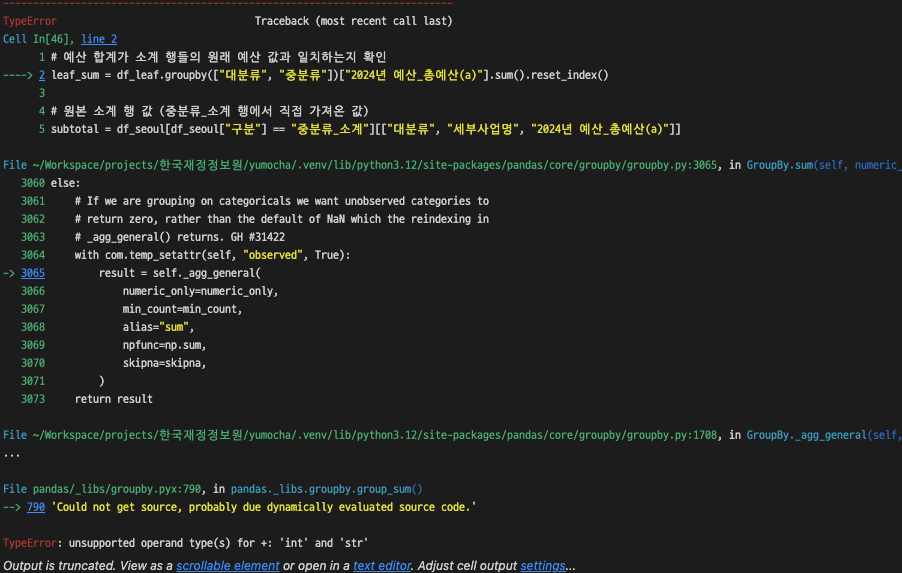
- 오류로 인해 타입확인 필요했음. 
- 페이지마다 세부사업명이 정확히 "세부사업명" (헤더 그대로)인 행들 확인하고 classify_row에 예외 추가 후 셀 재실행


In [14]:
# 세부사업명이 정확히 "세부사업명" (헤더 그대로)인 행들 확인
df_leaf[df_leaf["세부사업명"]=="세부사업명"]

,세부사업명,공통/자체,2024년예산_총예산(a),2023년예산(최종예산)_총예산(b),증감내역_증감액(a-b),증감내역_증감율,주요내용,대분류,중분류


In [ ]:
# 예산 합계가 소계 행들의 원래 예산 값과 일치하는지 확인
leaf_sum = df_leaf.groupby(["대분류", "중분류"])["2024년예산_총예산(a)"].sum().reset_index()

# 원본 소계 행 값 (중분류_소계 행에서 직접 가져온 값)
subtotal = df_seoul[df_seoul["구분"] == "중분류_소계"][["대분류", "세부사업명", "2024년예산_총예산(a)"]]
subtotal = subtotal.rename(columns={"세부사업명": "중분류", "2024년예산_총예산(a)": "원본_소계값"})

qa = leaf_sum.merge(subtotal, on=["대분류", "중분류"], how="left")
qa["차이"] = qa["2024년예산_총예산(a)"] - qa["원본_소계값"]

# 결과 컬럼을 항상 채워서, 저장 파일이 비어있어도 "검증은 했다"는 게 남도록 함
qa["결과"] = qa["차이"].abs().le(0.01).map({True: "일치", False: "불일치"})

qa_mismatch = qa[qa["결과"] == "불일치"]
print(f"검증 대상: {len(qa)}건 / 불일치: {len(qa_mismatch)}건")
qa

[발견한 오류 2]
---



4번 중분류로 들어가야하는데 3번 중분류로 들어가 있었음.


-> `classify_row` 에서 원래는 주요내용이 비어있으면 체크했는데, 이를 빼고 숫자. 으로 시작하면 중분류_소계로 판단하는 로직으로 변경


=> **수정 후 예산 불일치 해결됨**

In [16]:
def find_budget_columns(columns: list[str]) -> dict:
  """컬럼명 안의 4자리 연도를 추출해 당해/전년 컬럼을 자동 판별"""
  years_col = {}
  for col in columns:
    if not isinstance(col, str):
      continue
    match = re.search(r"(20\d{2})", col)
    if match and "예산" in col and "증감" not in col: 
      years_col[int(match.group(1))] = col
    
  if len(years_col) != 2:
    raise ValueError(f"예산 연도 컬럼을 정확히 2개 찾지 못함: {years_col}")
  당해년도 = max(years_col)
  전년도 = min(years_col)
  return {
    "당해년도": 당해년도,
    "전년도": 전년도,
    "당해_컬럼명": years_col[당해년도],
    "전년_컬럼명": years_col[전년도]
  }

year_info = find_budget_columns(df_leaf.columns.tolist())
print(year_info)

df_leaf = df_leaf.rename(columns={
  year_info["당해_컬럼명"]: "예산_당해년도",
  year_info["전년_컬럼명"]: "예산_전년도_최종"
})

df_leaf.columns.tolist()

{'당해년도': 2024, '전년도': 2023, '당해_컬럼명': '2024년예산_총예산(a)', '전년_컬럼명': '2023년예산(최종예산)_총예산(b)'}


['세부사업명',
 '공통/자체',
 '예산_당해년도',
 '예산_전년도_최종',
 '증감내역_증감액(a-b)',
 '증감내역_증감율',
 '주요내용',
 '대분류',
 '중분류']

In [17]:
df_long = df_leaf.melt(
  id_vars=["세부사업명", "공통/자체", "주요내용", "대분류", "중분류"],
  value_vars=["예산_당해년도", "예산_전년도_최종"],
  var_name="연도구분",
  value_name="예산액"
)

df_long["연도"] = df_long["연도구분"].map({
  "예산_당해년도": year_info["당해년도"],
  "예산_전년도_최종": year_info["전년도"]
})

df_long = df_long.drop(columns=["연도구분"])
df_long.head(10)

,세부사업명,공통/자체,주요내용,대분류,중분류,예산액,연도
0,저출생 극복 지역네트워크 구축사업 지원,공통,지원대상 : 서울시민(3~7세 자녀가 있는 가정) 지원내용:서울100인의아빠단,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),54,2024
1,입양아동 가족지원,공통,"지원대상 : 입양특례법에 의한 18세미만 입양 아동 및 그 가정 지원내용:입양아동양육보조금,양육수당,입양비용등",Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),4002,2024
2,국공립어린이집 등 보육서비스 수준제고,공통,지원대상 : 국공립 어린이집 등 지원내용:보육교직원인건비지원,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),459506,2024
3,어린이집 이용 영유아 무상보육 확대,공통,지원대상 : 만0~2세 영아 지원내용:어린이집이용영아대상바우처지원,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),554805,2024
4,초등돌봄 공적 인프라 확충,공통,지원대상 : 6~12세 아동 지원내용:돌봄서비스제공,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),1141,2024
5,육아종합지원센터 운영,공통,"지원대상 : 어린이집 및 영유아 양육 가정 지원내용 어린이집 지원사업 : 어린이집 맞춤 컨설팅, 장애아지원 교육 보육교직원 교육 및 상담, 서울형 모아어린이집 운영지원 등 가정양육 지원사업 : 장난감도서관 운영, 시 간제보육 관리등",Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),2244,2024
6,가정양육수당 지원,공통,지원대상 : 시설 미이용 24개월~86개월 미만 아동 지원내용:월10만원(장애아동35개월미만20만원) 지원,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),44151,2024
7,부모급여,공통,"지원대상 : 0~1세 아동 지원내용:0세100만원(월),1세50만원(월)지원",Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),688871,2024
8,공동육아나눔터,공통,"지원대상 : 자녀를 둔 가정(자녀 및 보호자) 지원내용:공동육아공간제공,가족품앗이활동지원",Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),2365,2024
9,아이돌봄서비스 확충 및 내실화,공통,지원대상 : 맞벌이 등 양육공백 가정의 만 12 세 이하 아동 지원내용:아이돌보미를연계해찾아가는아이돌봄 서비스제공,Ⅰ. 공통사업,1. 함께 일하고 함께 돌보는 사회(공통),96810,2024


In [ ]:
SIDO_INTERIM_DIR = INTERIM_DIR / "서울특별시"
SIDO_INTERIM_DIR.mkdir(parents=True, exist_ok=True)

df_leaf = df_leaf.reset_index(drop=True)
df_leaf.to_csv(SIDO_INTERIM_DIR / "2024_서울특별시_세부사업_정제.csv", index=False, encoding='utf-8-sig')

df_long = df_long.reset_index(drop=True)
df_long.to_csv(SIDO_INTERIM_DIR / "2024_서울특별시_세부사업_정제_long.csv", index=False, encoding='utf-8-sig')

# 필터링 전 전체 원본 (소계·헤더반복 노이즈까지 다 포함, QA/감사용 보관)
df_seoul.to_csv(SIDO_INTERIM_DIR / "2024_서울특별시_필터링전_전체원본.csv", index=False, encoding='utf-8-sig')

# 검증 대상 전체를 결과(일치/불일치)와 함께 저장 - 불일치가 0건이어도 "몇 건을 검증해서 다 맞았다"가 파일에 남음
qa.to_csv(
  REPORTS_DIR / "2024_서울특별시_QA_검증결과.csv", index=False, encoding='utf-8-sig'
)
print("저장 완료: ")
print("-", SIDO_INTERIM_DIR / "2024_서울특별시_세부사업_정제.csv")
print("-", SIDO_INTERIM_DIR / "2024_서울특별시_세부사업_정제_long.csv")
print("-", SIDO_INTERIM_DIR / "2024_서울특별시_필터링전_전체원본.csv")
print("-", REPORTS_DIR / "2024_서울특별시_QA_검증결과.csv")
print(f"QA 검증 대상 {len(qa)}건 중 불일치 {len(qa_mismatch)}건")